In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
ms = pd.read_csv('/Users/shubhrajitpal/Documents/Python_DS/Badminton_practice/archive (7)/ms.csv')

In [511]:
ms.head()

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,4.0,4.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-..."
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,6.0,5.0,2.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[]
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,2.0,6.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-..."
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,12.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[]
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,3.0,4.0,0.0,2.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[]


In [513]:
ms.shape

(3761, 38)

In [515]:
ms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 38 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tournament                               3761 non-null   object 
 1   city                                     3761 non-null   object 
 2   country                                  3761 non-null   object 
 3   date                                     3761 non-null   object 
 4   tournament_type                          3761 non-null   object 
 5   discipline                               3761 non-null   object 
 6   round                                    3761 non-null   object 
 7   winner                                   3761 non-null   int64  
 8   nb_sets                                  3761 non-null   int64  
 9   retired                                  3761 non-null   bool   
 10  game_1_score                             3761 no

In [ ]:
# Some team name in ms.csv in columns: teamone and teamtwo are different like shiFengli and Shi FengLi.
# which is being taken care below

In [614]:
ms['team_one_players_normal']=ms['team_one_players'].str.lower().str.replace(' ','',regex= False)
unique_team1 = ms['team_one_players_normal'].unique()

In [616]:
ms['team_two_players_normal'] = ms['team_two_players'].str.lower().str.replace(' ','',regex= False)
unique_team2 = ms['team_two_players_normal'].unique()

In [619]:
from fuzzywuzzy import fuzz

standard_threshold = 90
match_map={}

for team1_name in unique_team1:
    best_score = 0
    best_match = None

    for team2_name in unique_team2:
        score = fuzz.token_sort_ratio(team1_name,team2_name)
        if (score > best_score):
            best_score = score
            best_match = ms[ms['team_two_players_normal'] == team2_name]['team_two_players'].iloc[0]
            
        if (best_score >= standard_threshold):
            # Dictionary to store mapping: {Col1_Clean_Value: Matched_Col2_Original_Value}
            match_map[team1_name] = best_match
        else:
            original_match = ms[ms['team_one_players_normal'] == team1_name]['team_one_players'].iloc[0]
            match_map[team1_name] = original_match


ms['team_1_updated'] = ms['team_one_players_normal'].map(match_map)
ms['team_one_players'] = ms['team_1_updated']

# df['Col2'] remains unchanged as it holds the standard string.

# Drop the temporary clean columns
ms = ms.drop(columns=['team_one_players_normal','team_two_players_normal','team_1_updated'])

In [1152]:
check1 = ms.groupby('team_one_players')['team_one_players'].size().index.sort_values().str.lower().tolist()

In [683]:
ms['team_one_players_normal']=ms['team_one_players'].str.lower().str.replace(' ','',regex= False)
unique_team1 = ms['team_one_players_normal'].unique()

ms['team_two_players_normal'] = ms['team_two_players'].str.lower().str.replace(' ','',regex= False)
unique_team2 = ms['team_two_players_normal'].unique()

from fuzzywuzzy import fuzz

standard_threshold = 90
match_map={}

for team1_name in unique_team1:
    best_score = 0
    best_match = None

    for team2_name in unique_team2:
        score = fuzz.token_sort_ratio(team2_name,team1_name)
        if (score > best_score):
            best_score = score
            best_match = ms[ms['team_one_players_normal'] == team1_name]['team_one_players'].iloc[0]
            
        if (best_score >= standard_threshold):
            # Dictionary to store mapping: {Col1_Clean_Value: Matched_Col2_Original_Value}
            match_map[team2_name] = best_match
        else:
            original_match = ms[ms['team_two_players_normal'] == team2_name]['team_two_players'].iloc[0]
            match_map[team2_name] = original_match


ms['team_2_updated'] = ms['team_two_players_normal'].map(match_map)
ms['team_two_players'] = ms['team_2_updated']

# df['Col2'] remains unchanged as it holds the standard string.

# Drop the temporary clean columns
ms = ms.drop(columns=['team_two_players_normal','team_one_players_normal','team_2_updated'])

In [689]:
ms_clean = ms.copy()

In [691]:
ms_clean.head(5)

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,4.0,4.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-..."
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,6.0,5.0,2.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[]
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,2.0,6.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-..."
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,12.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[]
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,3.0,4.0,0.0,2.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[]


In [706]:
ms_clean.groupby('team_two_players')['team_two_players'].unique()

team_two_players
Abdul Kadir Zailani    [Abdul Kadir Zailani]
Abhinav Manota              [Abhinav Manota]
Abhishek Yelegar          [Abhishek Yelegar]
Abhishek Yeligar          [Abhishek Yeligar]
Abhyansh Singh              [Abhyansh Singh]
                               ...          
Zhengxing Wang              [Zhengxing Wang]
Zhengze Gao                    [Zhengze Gao]
Zii Jia Lee                    [Zii Jia Lee]
Zin Rei Ryan Ng            [Zin Rei Ryan Ng]
Zvonimir Durkinjak      [Zvonimir Durkinjak]
Name: team_two_players, Length: 476, dtype: object

In [708]:
ms.groupby('team_one_players')['team_one_players'].unique()

team_one_players
Aaron Sangga Wijaya    [Aaron Sangga Wijaya]
Aaron Zhao                      [Aaron Zhao]
Abdul Kadir Zailani    [Abdul Kadir Zailani]
Abhinav Manota              [Abhinav Manota]
Abhishek Kulkarni        [Abhishek Kulkarni]
                               ...          
Zii Jia Lee                    [Zii Jia Lee]
Zin Rei Ryan Ng            [Zin Rei Ryan Ng]
Zulfadli Zulkiffli      [Zulfadli Zulkiffli]
Zulhelmi Zulkiffli      [Zulhelmi Zulkiffli]
Zvonimir Durkinjak      [Zvonimir Durkinjak]
Name: team_one_players, Length: 494, dtype: object

In [710]:
ms_clean['team_two_players'] = ms_clean['team_two_players'].replace('Abhishek Yelegar', 'Abhishek Yeligar')

In [718]:
ms_clean['team_one_players'] = ms_clean['team_one_players'].replace('Abhishek Yelegar', 'Abhishek Yeligar')

In [1093]:
# sdf = ms_clean[(ms_clean['team_one_players'].str.lower()=='arintap das gupta') | (ms_clean['team_two_players'].str.lower()=='arintap das gupta')]

In [1099]:
#sdf

In [1101]:
#r1 = sdf[(sdf['winner']==1) & (sdf['team_one_players'].str.lower()=='subhankar dey')].shape[0]

In [1103]:
#r2 = sdf[(sdf['winner']==2) & (sdf['team_two_players'].str.lower()=='subhankar dey')].shape[0]

In [1105]:
#win_sdf = r1+r2
#win_sdf

In [1109]:
#win_percent_sdf = (win_sdf/sdf.shape[0])*100
#win_percent_sdf

# 1. Who’s the most dominant Singles player?

Goal: Find the player with the highest win rate in Singles matches (min. 80 matches played).
→ What does this say about consistency or dominance?

In [999]:
match_count_tt1 = ms_clean.groupby('team_one_players')['team_one_players'].value_counts() + ms_clean.groupby('team_two_players')['team_two_players'].value_counts()
match_count_tt1_bool = (ms_clean.groupby('team_one_players')['team_one_players'].value_counts() + ms_clean.groupby('team_two_players')['team_two_players'].value_counts()) >=100
players_selected = match_count_tt1[match_count_tt1_bool].index.tolist()

In [1001]:
len(players_selected)

5

In [131]:
ms.groupby('team_one_players')['team_one_players'].value_counts() + ms.groupby('team_two_players')['team_two_players'].value_counts()

Aaron Sangga Wijaya     NaN
Aaron Zhao              NaN
Abdul Kadir Zailani     5.0
Abhinav Manota          9.0
Abhishek Kulkarni       NaN
                       ... 
Zii Jia Lee            84.0
Zin Rei Ryan Ng         4.0
Zulfadli Zulkiffli      NaN
Zulhelmi Zulkiffli      NaN
Zvonimir Durkinjak     12.0
Name: count, Length: 610, dtype: float64

In [129]:
ms.groupby('team_two_players')['team_two_players'].value_counts()

team_two_players
Abdul Kadir Zailani     1
Abhinav Manota          6
Abhishek Yelegar        3
Abhishek Yeligar        3
Abhyansh Singh          1
                       ..
Zhengxing Wang          1
Zhengze Gao             3
Zii Jia Lee            42
Zin Rei Ryan Ng         3
Zvonimir Durkinjak      5
Name: count, Length: 497, dtype: int64

In [1003]:
match_count_tt1[match_count_tt1_bool]

Anthony Sinisuka Ginting    105.0
Jonatan Christie            102.0
Kento Momota                117.0
Tien Chen Chou              136.0
Viktor Axelsen              119.0
Name: count, dtype: float64

In [1005]:
ps1 = ms_clean[
(
(ms_clean['team_one_players'].isin(players_selected))
)
]

In [1007]:
total_match_as_team1 = ps1.groupby('team_one_players')['team_one_players'].value_counts()
total_match_as_team1

team_one_players
Anthony Sinisuka Ginting    54
Jonatan Christie            41
Kento Momota                93
Tien Chen Chou              59
Viktor Axelsen              78
Name: count, dtype: int64

In [1009]:
match_won_as_team1 = ps1[ps1['winner']==1]['team_one_players'].value_counts()
match_won_as_team1

team_one_players
Kento Momota                81
Viktor Axelsen              62
Tien Chen Chou              44
Anthony Sinisuka Ginting    36
Jonatan Christie            28
Name: count, dtype: int64

In [1011]:
ps2 = ms_clean[
(
(ms_clean['team_two_players'].isin(players_selected))
)
]

In [1013]:
total_match_as_team2 = ps2.groupby('team_two_players')['team_two_players'].value_counts()
total_match_as_team2

team_two_players
Anthony Sinisuka Ginting    51
Jonatan Christie            61
Kento Momota                24
Tien Chen Chou              77
Viktor Axelsen              41
Name: count, dtype: int64

In [1015]:
match_won_as_team2 = ps2[ps2['winner']==2]['team_two_players'].value_counts()
match_won_as_team2

team_two_players
Tien Chen Chou              53
Jonatan Christie            37
Viktor Axelsen              30
Anthony Sinisuka Ginting    27
Kento Momota                20
Name: count, dtype: int64

In [1017]:
total_matches = total_match_as_team1 + total_match_as_team2
total_matches

team_one_players
Anthony Sinisuka Ginting    105
Jonatan Christie            102
Kento Momota                117
Tien Chen Chou              136
Viktor Axelsen              119
Name: count, dtype: int64

In [1019]:
matches_won = match_won_as_team1 + match_won_as_team2
matches_won

Anthony Sinisuka Ginting     63
Jonatan Christie             65
Kento Momota                101
Tien Chen Chou               97
Viktor Axelsen               92
Name: count, dtype: int64

In [1118]:
result = (matches_won/total_matches)*100
result.sort_values(ascending = False).head(1).index[0]

'Kento Momota'

# 2. Which country dominates Doubles tournaments?

Goal: Group Doubles matches by team nationalities (e.g., INA vs JPN) and find the pair of countries with the highest win ratio.
→ Which countries have strong doubles programs?

In [55]:
md = pd.read_csv('/Users/shubhrajitpal/Documents/Python_DS/Badminton_practice/archive (7)/md.csv')

In [1131]:
md.head()


,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MD,Qualification quarter final,1,3,False,...,2.0,3.0,0.0,1.0,"['0-0', '0-1', '0-2', '1-2', '1-3', '1-4', '2-...",7.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '2-1', '2-2', '3-2', '3-..."
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MD,Qualification quarter final,1,2,False,...,7.0,3.0,4.0,0.0,"['0-0', '1-0', '1-1', '2-1', '2-2', '2-3', '3-...",NaN,NaN,NaN,NaN,[]
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MD,Qualification quarter final,2,3,False,...,3.0,3.0,2.0,3.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",3.0,6.0,0.0,1.0,"['0-0', '1-0', '1-1', '2-1', '2-2', '3-2', '4-..."
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MD,Qualification quarter final,2,2,False,...,3.0,5.0,0.0,3.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '2-...",NaN,NaN,NaN,NaN,[]
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,10-01-2018,HSBC BWF World Tour Super 300,MD,Round of 32,1,3,False,...,3.0,4.0,0.0,2.0,"['0-0', '0-1', '0-2', '1-2', '1-3', '1-4', '2-...",4.0,2.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '1-3', '2-3', '2-..."


In [1133]:
md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2804 entries, 0 to 2803
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tournament                               2804 non-null   object 
 1   city                                     2804 non-null   object 
 2   country                                  2804 non-null   object 
 3   date                                     2804 non-null   object 
 4   tournament_type                          2804 non-null   object 
 5   discipline                               2804 non-null   object 
 6   round                                    2804 non-null   object 
 7   winner                                   2804 non-null   int64  
 8   nb_sets                                  2804 non-null   int64  
 9   retired                                  2804 non-null   bool   
 10  game_1_score                             2804 no

In [1301]:
md[['team_one_player_one','team_one_player_two','team_one_player_one_nationality','team_one_player_two_nationality']]
md.shape[0] == md[md['team_one_player_one_nationality'] == md['team_one_player_two_nationality']].shape[0]
# so every row point a team who has the team one nationality == team two nationality

True

In [1333]:
# The problem we see here is the column 'team_two_player_one' and 'team_two_player_two' has the same value.
# We need to see if the value of 'team_two_player_one' is present in the 'team_one_player_one' , 
# then we replace 'team_two_player_two' with 'team_one_player_two'

In [94]:
md['team_one_player_one_doubles']=md['team_one_player_one'].str.lower().str.replace(' ','',regex= False)
unique_team1 = md['team_one_player_one_doubles'].unique()

md['team_two_player_one_doubles'] = md['team_two_player_one'].str.lower().str.replace(' ','',regex= False)
unique_team2 = md['team_two_player_one_doubles'].unique()

from fuzzywuzzy import fuzz

standard_threshold = 90
match_map={}

for team2_name in unique_team2:
    best_score = 0
    best_match = None

    for team1_name in unique_team1:
        score = fuzz.token_sort_ratio(team1_name,team2_name)
        if (score > best_score):
            best_score = score
            best_match = md[md['team_one_player_one_doubles'] == team1_name]['team_one_player_two'].iloc[0]
            
        if (best_score >= standard_threshold):
            # Dictionary to store mapping: {Col1_Clean_Value: Matched_Col2_Original_Value}
            match_map[team2_name] = best_match
            #print ('ff:',index_match,team2_name,best_match)
            #break
        else:
            original_match = md[md['team_two_player_one_doubles'] == team2_name]['team_two_player_two'].iloc[0]
            match_map[team2_name] = original_match
            #print ('pp:',index_match,team2_name,original_match)

md['team_2_2_updated'] = md['team_two_player_one_doubles'].map(match_map)
md['team_two_player_two'] = md['team_2_2_updated']

In [99]:
# Drop the temporary clean columns
md = md.drop(columns=['team_two_player_one_doubles','team_one_player_one_doubles','team_2_2_updated'])

In [103]:
md_clean = md.copy()

In [558]:
doubles_pair_1 = md_clean.groupby(['team_one_player_one','team_one_player_two'])[['team_one_player_one','team_one_player_two','team_one_player_one_nationality','team_one_player_two_nationality']].value_counts()
doubles_pair_1_bool = md_clean.groupby(['team_one_player_one','team_one_player_two'])[['team_one_player_one','team_one_player_two','team_one_player_one_nationality','team_one_player_two_nationality']].value_counts()>=50
dd1 = doubles_pair_1[doubles_pair_1_bool]

In [560]:
dd1

team_one_player_one     team_one_player_two      team_one_player_one_nationality  team_one_player_two_nationality
Aaron Chia              Wooi Yik Soh             MAS                              MAS                                 61
Ching Yao Lu            Po Han Yang              TPE                              TPE                                 55
Fajar Alfian            Muhammad Rian Ardianto   INA                              INA                                 51
Marcus Ellis            Chris Langridge          ENG                              ENG                                 50
Marcus Fernaldi Gideon  Kevin Sanjaya Sukamuljo  INA                              INA                                125
Takeshi Kamura          Keigo Sonoda             JPN                              JPN                                 59
V Shem Goh              Wee Kiong Tan            MAS                              MAS                                 50
Name: count, dtype: int64

In [554]:
doubles_pair_2 = md_clean.groupby(['team_two_player_one','team_two_player_two'])[['team_two_player_one','team_two_player_two','team_two_player_one_nationality','team_two_player_two_nationality']].value_counts()
doubles_pair_2_bool = md_clean.groupby(['team_two_player_one','team_two_player_two'])[['team_two_player_one','team_two_player_two','team_two_player_one_nationality','team_two_player_two_nationality']].value_counts()>=50
dd2 = doubles_pair_2[doubles_pair_2_bool]

In [556]:
dd2

team_two_player_one  team_two_player_two     team_two_player_one_nationality  team_two_player_two_nationality
Fajar Alfian         Muhammad Rian Ardianto  INA                              INA                                 51
Mohammad Ahsan       Hendra Setiawan         INA                              INA                                100
Yang Lee             Chi-Lin Wang            TPE                              TPE                                 51
Name: count, dtype: int64

In [562]:
# Convert MultiIndex to columns and reset the name of the value column to 'count'
df1 = dd1.reset_index(name='count')

In [564]:
df1

,team_one_player_one,team_one_player_two,team_one_player_one_nationality,team_one_player_two_nationality,count
0,Aaron Chia,Wooi Yik Soh,MAS,MAS,61
1,Ching Yao Lu,Po Han Yang,TPE,TPE,55
2,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,51
3,Marcus Ellis,Chris Langridge,ENG,ENG,50
4,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,125
5,Takeshi Kamura,Keigo Sonoda,JPN,JPN,59
6,V Shem Goh,Wee Kiong Tan,MAS,MAS,50


In [574]:
# Rename the player columns to a standard format for merging
df1.rename(columns={
    'team_one_player_one': 'player_one',
    'team_one_player_two': 'player_two',
    'team_one_player_one_nationality': 'player_one_nationality',
    'team_one_player_two_nationality': 'player_two_nationality'    
}, inplace=True)

In [576]:
df1

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Aaron Chia,Wooi Yik Soh,MAS,MAS,61
1,Ching Yao Lu,Po Han Yang,TPE,TPE,55
2,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,51
3,Marcus Ellis,Chris Langridge,ENG,ENG,50
4,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,125
5,Takeshi Kamura,Keigo Sonoda,JPN,JPN,59
6,V Shem Goh,Wee Kiong Tan,MAS,MAS,50


In [578]:
dd2

team_two_player_one  team_two_player_two     team_two_player_one_nationality  team_two_player_two_nationality
Fajar Alfian         Muhammad Rian Ardianto  INA                              INA                                 51
Mohammad Ahsan       Hendra Setiawan         INA                              INA                                100
Yang Lee             Chi-Lin Wang            TPE                              TPE                                 51
Name: count, dtype: int64

In [580]:
# Convert MultiIndex to columns and reset the name of the value column to 'count'
df2 = dd2.reset_index(name='count')
df2

,team_two_player_one,team_two_player_two,team_two_player_one_nationality,team_two_player_two_nationality,count
0,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,51
1,Mohammad Ahsan,Hendra Setiawan,INA,INA,100
2,Yang Lee,Chi-Lin Wang,TPE,TPE,51


In [582]:
# Rename the player columns to the same standard format
df2.rename(columns={
    'team_two_player_one' : 'player_one',
    'team_two_player_two' : 'player_two',
    'team_two_player_one_nationality': 'player_one_nationality',
    'team_two_player_two_nationality': 'player_two_nationality'
}, inplace=True)

df2

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,51
1,Mohammad Ahsan,Hendra Setiawan,INA,INA,100
2,Yang Lee,Chi-Lin Wang,TPE,TPE,51


In [584]:
# Combine the two DataFrames vertically
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Aaron Chia,Wooi Yik Soh,MAS,MAS,61
1,Ching Yao Lu,Po Han Yang,TPE,TPE,55
2,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,51
3,Marcus Ellis,Chris Langridge,ENG,ENG,50
4,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,125
5,Takeshi Kamura,Keigo Sonoda,JPN,JPN,59
6,V Shem Goh,Wee Kiong Tan,MAS,MAS,50
7,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,51
8,Mohammad Ahsan,Hendra Setiawan,INA,INA,100
9,Yang Lee,Chi-Lin Wang,TPE,TPE,51


In [612]:
total_match_count = combined_df.groupby(['player_one','player_two','player_one_nationality','player_two_nationality']).sum()
total_match_count

,,,,count
player_one,player_two,player_one_nationality,player_two_nationality,
Aaron Chia,Wooi Yik Soh,MAS,MAS,61
Ching Yao Lu,Po Han Yang,TPE,TPE,55
Fajar Alfian,Muhammad Rian Ardianto,INA,INA,102
Marcus Ellis,Chris Langridge,ENG,ENG,50
Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,125
Mohammad Ahsan,Hendra Setiawan,INA,INA,100
Takeshi Kamura,Keigo Sonoda,JPN,JPN,59
V Shem Goh,Wee Kiong Tan,MAS,MAS,50
Yang Lee,Chi-Lin Wang,TPE,TPE,51


In [588]:
best_team_one_player_one = dd1.index.get_level_values(0).tolist()
best_team_one_player_one

['Aaron Chia',
 'Ching Yao Lu',
 'Fajar Alfian',
 'Marcus Ellis',
 'Marcus Fernaldi Gideon',
 'Takeshi Kamura',
 'V Shem Goh']

In [590]:
best_team_one_player_two = dd1.index.get_level_values(1).tolist()
best_team_one_player_two

['Wooi Yik Soh',
 'Po Han Yang',
 'Muhammad Rian Ardianto',
 'Chris Langridge',
 'Kevin Sanjaya Sukamuljo',
 'Keigo Sonoda',
 'Wee Kiong Tan']

In [592]:
best_team_two_player_one = dd2.index.get_level_values(0).tolist()
best_team_two_player_one

['Fajar Alfian', 'Mohammad Ahsan', 'Yang Lee']

In [594]:
best_team_two_player_two = dd2.index.get_level_values(1).tolist()
best_team_two_player_two

['Muhammad Rian Ardianto', 'Hendra Setiawan', 'Chi-Lin Wang']

In [596]:
team1 = md_clean[(md_clean['team_one_player_one'].isin(best_team_one_player_one)) & (md_clean['team_one_player_two'].isin(best_team_one_player_two))]

In [598]:
team1_won = team1[team1['winner']==1]

In [600]:
dfw1 = team1_won.groupby(['team_one_player_one','team_one_player_two'])[['team_one_player_one','team_one_player_two','team_one_player_one_nationality','team_one_player_two_nationality']].value_counts().reset_index()
dfw1

,team_one_player_one,team_one_player_two,team_one_player_one_nationality,team_one_player_two_nationality,count
0,Aaron Chia,Wooi Yik Soh,MAS,MAS,37
1,Ching Yao Lu,Po Han Yang,TPE,TPE,27
2,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,34
3,Marcus Ellis,Chris Langridge,ENG,ENG,31
4,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,111
5,Takeshi Kamura,Keigo Sonoda,JPN,JPN,40
6,V Shem Goh,Wee Kiong Tan,MAS,MAS,25


In [604]:
# Rename the player columns to a standard format for merging
dfw1.rename(columns={
    'team_one_player_one': 'player_one',
    'team_one_player_two': 'player_two',
    'team_one_player_one_nationality': 'player_one_nationality',
    'team_one_player_two_nationality': 'player_two_nationality'
}, inplace=True)
dfw1

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Aaron Chia,Wooi Yik Soh,MAS,MAS,37
1,Ching Yao Lu,Po Han Yang,TPE,TPE,27
2,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,34
3,Marcus Ellis,Chris Langridge,ENG,ENG,31
4,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,111
5,Takeshi Kamura,Keigo Sonoda,JPN,JPN,40
6,V Shem Goh,Wee Kiong Tan,MAS,MAS,25


In [197]:
team2 = md_clean[(md_clean['team_two_player_one'].isin(best_team_two_player_one)) & (md_clean['team_two_player_two'].isin(best_team_two_player_two))]

In [199]:
team2_won = team2[team2['winner']==2]

In [552]:
dfw2 = team2_won.groupby(['team_two_player_one','team_two_player_two'])[['team_two_player_one','team_two_player_two','team_two_player_one_nationality','team_two_player_two_nationality']].value_counts().reset_index()
dfw2

,team_two_player_one,team_two_player_two,team_two_player_one_nationality,team_two_player_two_nationality,count
0,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,36
1,Mohammad Ahsan,Hendra Setiawan,INA,INA,75
2,Yang Lee,Chi-Lin Wang,TPE,TPE,39


In [606]:
# Rename the player columns to a standard format for merging
dfw2.rename(columns={
    'team_two_player_one': 'player_one',
    'team_two_player_two': 'player_two',
    'team_two_player_one_nationality': 'player_one_nationality',
    'team_two_player_two_nationality': 'player_two_nationality'
}, inplace=True)
dfw2

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,36
1,Mohammad Ahsan,Hendra Setiawan,INA,INA,75
2,Yang Lee,Chi-Lin Wang,TPE,TPE,39


In [608]:
# Combine the two DataFrames vertically
combined_dfw = pd.concat([dfw1, dfw2], ignore_index=True)
combined_dfw

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Aaron Chia,Wooi Yik Soh,MAS,MAS,37
1,Ching Yao Lu,Po Han Yang,TPE,TPE,27
2,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,34
3,Marcus Ellis,Chris Langridge,ENG,ENG,31
4,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,111
5,Takeshi Kamura,Keigo Sonoda,JPN,JPN,40
6,V Shem Goh,Wee Kiong Tan,MAS,MAS,25
7,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,36
8,Mohammad Ahsan,Hendra Setiawan,INA,INA,75
9,Yang Lee,Chi-Lin Wang,TPE,TPE,39


In [614]:
total_match_count_win = combined_dfw.groupby(['player_one','player_two','player_one_nationality','player_two_nationality']).sum()
total_match_count_win

,,,,count
player_one,player_two,player_one_nationality,player_two_nationality,
Aaron Chia,Wooi Yik Soh,MAS,MAS,37
Ching Yao Lu,Po Han Yang,TPE,TPE,27
Fajar Alfian,Muhammad Rian Ardianto,INA,INA,70
Marcus Ellis,Chris Langridge,ENG,ENG,31
Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,111
Mohammad Ahsan,Hendra Setiawan,INA,INA,75
Takeshi Kamura,Keigo Sonoda,JPN,JPN,40
V Shem Goh,Wee Kiong Tan,MAS,MAS,25
Yang Lee,Chi-Lin Wang,TPE,TPE,39


In [622]:
doubles_win_rate = (total_match_count_win/total_match_count)*100
best_doubles_team = doubles_win_rate['count'].sort_values(ascending = False)
best_doubles_team.reset_index()

,player_one,player_two,player_one_nationality,player_two_nationality,count
0,Marcus Fernaldi Gideon,Kevin Sanjaya Sukamuljo,INA,INA,88.800000
1,Yang Lee,Chi-Lin Wang,TPE,TPE,76.470588
2,Mohammad Ahsan,Hendra Setiawan,INA,INA,75.000000
3,Fajar Alfian,Muhammad Rian Ardianto,INA,INA,68.627451
4,Takeshi Kamura,Keigo Sonoda,JPN,JPN,67.796610
5,Marcus Ellis,Chris Langridge,ENG,ENG,62.000000
6,Aaron Chia,Wooi Yik Soh,MAS,MAS,60.655738
7,V Shem Goh,Wee Kiong Tan,MAS,MAS,50.000000
8,Ching Yao Lu,Po Han Yang,TPE,TPE,49.090909


In [650]:
country = best_doubles_team.reset_index()
country.groupby(['player_one_nationality','player_two_nationality']).count()['count'].sort_values(ascending = False).reset_index()

,player_one_nationality,player_two_nationality,count
0,INA,INA,3
1,MAS,MAS,2
2,TPE,TPE,2
3,ENG,ENG,1
4,JPN,JPN,1


In [654]:
# The Mens Doubles is dominated by Indonesia

# 3. Does tournament type affect match intensity?

Goal: Compare average number of sets played in Super 100 vs Super 1000 tournaments.
→ Do higher-level tournaments have closer, tougher matches?

In [658]:
md_clean['tournament_type'].unique()

array(['HSBC BWF World Tour Super 300', 'HSBC BWF World Tour Super 500',
       'HSBC BWF World Tour Super 1000', 'BWF Tour Super 100',
       'HSBC BWF World Tour Super 750', 'HSBC BWF World Tour Finals'],
      dtype=object)

In [676]:
#The ranking of the tournaments are : 

# Ranking of BWF Tournaments

#### Rank1 = HSBC BWF World Tour Finals;
#### Rank2 = HSBC BWF World Tour Super 1000;
#### Rank3 = HSBC BWF World Tour Super 750;
#### Rank4 =	HSBC BWF World Tour Super 500;
#### Rank5 =	HSBC BWF World Tour Super 300;
#### Rank6 =	BWF Tour Super 100;

In [733]:
md_clean[md_clean['retired']==False].groupby('tournament_type')['nb_sets'].value_counts()

tournament_type                 nb_sets
BWF Tour Super 100              2          503
                                3          240
HSBC BWF World Tour Finals      2           28
                                3           16
HSBC BWF World Tour Super 1000  2          190
                                3          112
HSBC BWF World Tour Super 300   2          533
                                3          272
HSBC BWF World Tour Super 500   2          368
                                3          183
HSBC BWF World Tour Super 750   2          212
                                3          120
Name: count, dtype: int64

In [735]:
(md_clean[md_clean['retired']==False].groupby('tournament_type')['nb_sets'].value_counts())/md_clean[md_clean['retired']==False].groupby('tournament_type')['nb_sets'].count()

tournament_type                 nb_sets
BWF Tour Super 100              2          0.676985
                                3          0.323015
HSBC BWF World Tour Finals      2          0.636364
                                3          0.363636
HSBC BWF World Tour Super 1000  2          0.629139
                                3          0.370861
HSBC BWF World Tour Super 300   2          0.662112
                                3          0.337888
HSBC BWF World Tour Super 500   2          0.667877
                                3          0.332123
HSBC BWF World Tour Super 750   2          0.638554
                                3          0.361446
dtype: float64

In [772]:
# The above fraction shows the avg match count w.r.t tournament type and nb_sets. so we see there is not much of a different in effort.
# when compared between games of 2 sets and 3 sets in each tournament. On avg its quite same. 
# We cant say higher-level tournaments have closer, tougher matches

In [776]:
md_clean.groupby('tournament_type')['nb_sets'].mean().sort_values(ascending=False).reset_index()
# different way to see the same result. above I have refined the query for better understanding

,tournament_type,nb_sets
0,HSBC BWF World Tour Super 1000,2.365132
1,HSBC BWF World Tour Finals,2.363636
2,HSBC BWF World Tour Super 750,2.357357
3,HSBC BWF World Tour Super 300,2.329253
4,HSBC BWF World Tour Super 500,2.326715
5,BWF Tour Super 100,2.311170


In [668]:
# We see there is no such thing as higher-level tournaments have closer, tougher matches

# 4. Do retired matches skew results?

Goal: Calculate how often matches end with a retired = True flag, and see how it varies by tournament type or round.
→ Any pattern with retirements in finals or early rounds?

In [689]:
rdf = md_clean[md_clean['retired']==True]

In [846]:
rdf.groupby('tournament_type')[['nb_sets']].value_counts().reset_index().sort_values(by=['nb_sets'],ascending=False)

,tournament_type,nb_sets,count
6,HSBC BWF World Tour Super 300,3,2
1,BWF Tour Super 100,2,3
3,HSBC BWF World Tour Super 1000,2,1
5,HSBC BWF World Tour Super 300,2,5
8,HSBC BWF World Tour Super 500,2,1
0,BWF Tour Super 100,1,6
2,HSBC BWF World Tour Super 1000,1,1
4,HSBC BWF World Tour Super 300,1,5
7,HSBC BWF World Tour Super 500,1,2
9,HSBC BWF World Tour Super 750,1,1


In [858]:
md_clean.groupby('tournament_type')['nb_sets'].count()

tournament_type
BWF Tour Super 100                752
HSBC BWF World Tour Finals         44
HSBC BWF World Tour Super 1000    304
HSBC BWF World Tour Super 300     817
HSBC BWF World Tour Super 500     554
HSBC BWF World Tour Super 750     333
Name: nb_sets, dtype: int64

In [866]:
rdf.groupby('tournament_type')['nb_sets'].value_counts()

tournament_type                 nb_sets
BWF Tour Super 100              1          6
                                2          3
HSBC BWF World Tour Super 1000  1          1
                                2          1
HSBC BWF World Tour Super 300   1          5
                                2          5
                                3          2
HSBC BWF World Tour Super 500   1          2
                                2          1
HSBC BWF World Tour Super 750   1          1
Name: count, dtype: int64

In [874]:
((rdf.groupby('tournament_type')['nb_sets'].count()/md_clean.groupby('tournament_type')['nb_sets'].count())*100).sort_values(ascending=False)

tournament_type
HSBC BWF World Tour Super 300     1.468788
BWF Tour Super 100                1.196809
HSBC BWF World Tour Super 1000    0.657895
HSBC BWF World Tour Super 500     0.541516
HSBC BWF World Tour Super 750     0.300300
HSBC BWF World Tour Finals             NaN
Name: nb_sets, dtype: float64

In [876]:
# percentage of retired matches grouped by tournament type : we see High level tournaments have less retired matches

In [886]:
rdf.groupby('tournament_type')[['nb_sets','round']].count().reset_index().sort_values(by=['nb_sets','tournament_type','round'],ascending=[False,False,False])

,tournament_type,nb_sets,round
2,HSBC BWF World Tour Super 300,12,12
0,BWF Tour Super 100,9,9
3,HSBC BWF World Tour Super 500,3,3
1,HSBC BWF World Tour Super 1000,2,2
4,HSBC BWF World Tour Super 750,1,1


In [834]:
rdf.groupby('tournament_type')[['nb_sets','round']].value_counts().reset_index().sort_values(by=['tournament_type','nb_sets','round'],ascending=[True,True,True])

,tournament_type,nb_sets,round,count
2,BWF Tour Super 100,1,Round of 16,1
0,BWF Tour Super 100,1,Round of 32,5
1,BWF Tour Super 100,2,Quarter final,2
3,BWF Tour Super 100,2,Semi final,1
4,HSBC BWF World Tour Super 1000,1,Round of 32,1
5,HSBC BWF World Tour Super 1000,2,Round of 32,1
8,HSBC BWF World Tour Super 300,1,Qualification quarter final,1
9,HSBC BWF World Tour Super 300,1,Round of 16,1
7,HSBC BWF World Tour Super 300,1,Round of 32,2
10,HSBC BWF World Tour Super 300,1,Semi final,1


In [890]:
# We see that for super 300, out of total 12 retired matches 6 happened in Round of 32.
# Similarly for super 100, out of total 9 retired matches 5 happened in Round of 32.

# We can conclude players playing the lowest level tournament maybe new to international tournaments and not accustomed to the
# physical strength the body needs to play at that level
# Also for high level tournament , players would tend to play inspite of injury as the points are more.

# 5. Who scores the most consecutive points in a game?

Goal: Find the max value of most_consecutive_points_game_i across all games, and identify the player or team.
→ What does this say about momentum in badminton?

In [954]:
doubles_pair_1_cp = md_clean.groupby(['team_one_player_one','team_one_player_two'])[['team_one_most_consecutive_points']].max()

In [956]:
doubles_pair_1_cp

,,team_one_most_consecutive_points
team_one_player_one,team_one_player_two,
Aaron Chia,Wooi Yik Soh,11
Adam Gozzi,Melker Z-Bexell,5
Adarsh Kumar,Jagadish Yadav,6
Akbar Bintang Cahyono,Moh Reza Pahlevi Isfahani,9
Akira Kobayashi,Kohtaro Miyajima,6
...,...,...
Zhiyi Dai,Kai Zheng,4
Zhuanyi Xuheng,Binrong Zhang,5
Zi Jian Di,Chang Wang,7


In [958]:
doubles_pair_2_cp = md_clean.groupby(['team_two_player_one','team_two_player_two'])[['team_two_most_consecutive_points']].max()

In [960]:
doubles_pair_2_cp

,,team_two_most_consecutive_points
team_two_player_one,team_two_player_two,
Aaron Chia,Wooi Yik Soh,8
Abhishek Ahlawat,Abhishek Ahlawat,4
Adam (Xingyu) Dong,Adam (Xingyu) Dong,4
Adam Gozzi,Melker Z-Bexell,4
Adam Jeffrey,Adam Jeffrey,3
...,...,...
Zhenbang Jiang,Binrong Zhang,5
Zhiyi Dai,Kai Zheng,8
Zi Jian Di,Chang Wang,7


In [962]:
doubles_pair_1_cp = doubles_pair_1_cp.reset_index()
doubles_pair_1_cp.rename(columns={
    'team_one_player_one': 'player_one',
    'team_one_player_two': 'player_two',
    'team_one_most_consecutive_points': 'consecutive_points'
}, inplace=True)

doubles_pair_1_cp

,player_one,player_two,consecutive_points
0,Aaron Chia,Wooi Yik Soh,11
1,Adam Gozzi,Melker Z-Bexell,5
2,Adarsh Kumar,Jagadish Yadav,6
3,Akbar Bintang Cahyono,Moh Reza Pahlevi Isfahani,9
4,Akira Kobayashi,Kohtaro Miyajima,6
...,...,...,...
502,Zhiyi Dai,Kai Zheng,4
503,Zhuanyi Xuheng,Binrong Zhang,5
504,Zi Jian Di,Chang Wang,7
505,Zijian Di,Chang Wang,7


In [964]:
doubles_pair_2_cp = doubles_pair_2_cp.reset_index()

doubles_pair_2_cp.rename(columns={
    'team_two_player_one': 'player_one',
    'team_two_player_two': 'player_two',
    'team_two_most_consecutive_points': 'consecutive_points'
}, inplace=True)
doubles_pair_2_cp

,player_one,player_two,consecutive_points
0,Aaron Chia,Wooi Yik Soh,8
1,Abhishek Ahlawat,Abhishek Ahlawat,4
2,Adam (Xingyu) Dong,Adam (Xingyu) Dong,4
3,Adam Gozzi,Melker Z-Bexell,4
4,Adam Jeffrey,Adam Jeffrey,3
...,...,...,...
413,Zhenbang Jiang,Binrong Zhang,5
414,Zhiyi Dai,Kai Zheng,8
415,Zi Jian Di,Chang Wang,7
416,Zicong Guan,Zicong Guan,5


In [966]:
type(doubles_pair_1_cp)

pandas.core.frame.DataFrame

In [968]:
combined_dfcp = pd.concat([doubles_pair_1_cp, doubles_pair_2_cp], ignore_index=True)
combined_dfcp

,player_one,player_two,consecutive_points
0,Aaron Chia,Wooi Yik Soh,11
1,Adam Gozzi,Melker Z-Bexell,5
2,Adarsh Kumar,Jagadish Yadav,6
3,Akbar Bintang Cahyono,Moh Reza Pahlevi Isfahani,9
4,Akira Kobayashi,Kohtaro Miyajima,6
...,...,...,...
920,Zhenbang Jiang,Binrong Zhang,5
921,Zhiyi Dai,Kai Zheng,8
922,Zi Jian Di,Chang Wang,7
923,Zicong Guan,Zicong Guan,5


In [979]:
combined_dfcp.groupby(['player_one','player_two'])['consecutive_points'].max().reset_index().sort_values(by=['consecutive_points'],ascending=[False]).head(10)

,player_one,player_two,consecutive_points
342,Mathias Boe,Mads Conrad-Petersen,19
184,Hiroyuki Endo,Yuta Watanabe,17
341,Mathias Boe,Carsten Mogensen,17
183,Hiroyuki ENDO,Yuta Watanabe,15
290,Ko-Chi Chang,Yu Hsien Lin,14
437,Raphael Beck,Andreas Heinz,14
235,Jones Ralfy Jansen,Josche Zurwonne,14
256,Kai Xiang Huang,Cheng Liu,14
501,Sihang Chen,Weijie Dong,13
242,Joshua Magee,Paul Reynolds,13


In [981]:
# Mathias Boe and Mads Conrad-Petersen took 19 points at a stretch

# 6. How often does the team with fewer total points win?

Goal: Compare team_one_total_points vs team_two_total_points, and count how often the losing team actually scored more.
→ Are match wins always fair reflections of performance?

In [987]:
win_pair_2_tp = md_clean[(md_clean['team_one_total_points']>md_clean['team_two_total_points']) & (md_clean['winner']==2)]

In [991]:
win_pair_1_tp = md_clean[(md_clean['team_one_total_points']<md_clean['team_two_total_points']) & (md_clean['winner']==1)]

In [1018]:
win_pair = win_pair_2_tp.shape[0] + win_pair_1_tp.shape[0]
win_pair

95

In [1026]:
losing_team_score_more_percent = (win_pair/md_clean[md['retired']==False].shape[0])*100
losing_team_score_more_percent

3.420957868203097

In [1028]:
# Are match wins always fair reflections of performance?
# Not always we have 3.5% or 95 total matches in 4 years where the losing team actually performed well w.r.t point scored
# but lost
# Also 3.5 is very very less so I would say usually the better team has more total score

# How common are straight-set wins?

Goal: Count how many matches ended in 2 sets vs 3 sets, separately for Singles and Doubles.
→ Are most matches close or one-sided?

In [1048]:
# Doubles match ended in 2 sets
md_clean[(md['nb_sets']==2) & (md['retired']==False)]['tournament_type'].value_counts()

tournament_type
HSBC BWF World Tour Super 300     533
BWF Tour Super 100                503
HSBC BWF World Tour Super 500     368
HSBC BWF World Tour Super 750     212
HSBC BWF World Tour Super 1000    190
HSBC BWF World Tour Finals         28
Name: count, dtype: int64

In [1042]:
# Doubles match ended in 2 sets
md_clean[(md['nb_sets']==3) & (md['retired']==False)]['tournament_type'].value_counts()

tournament_type
HSBC BWF World Tour Super 300     272
BWF Tour Super 100                240
HSBC BWF World Tour Super 500     183
HSBC BWF World Tour Super 750     120
HSBC BWF World Tour Super 1000    112
HSBC BWF World Tour Finals         16
Name: count, dtype: int64

In [ ]:
# Are most matches close or one-sided?
# Most matches in all tournament types are mostly 2 sets.

# Are certain months or seasons more intense?

Goal: Extract the month from the date column and compare total matches played and average points scored by month.
→ Is there a "busy season" in professional badminton?

In [1094]:
# Storing the months of the date in a new column : md_clean['date_time_format'] 
md_clean['date_time_format'] = pd.to_datetime(md_clean['date'],format='%d-%m-%Y')
md_clean['date_time_format'] = md_clean['date_time_format'].dt.month

In [1110]:
month_counts = md_clean.groupby('date_time_format')['date_time_format'].count().reset_index(name='count')

In [1112]:
month_counts

,date_time_format,count
0,1,409
1,2,131
2,3,388
3,4,93
4,5,98
5,6,134
6,7,310
7,8,146
8,9,315
9,10,397


In [1078]:
import matplotlib.pyplot as plt

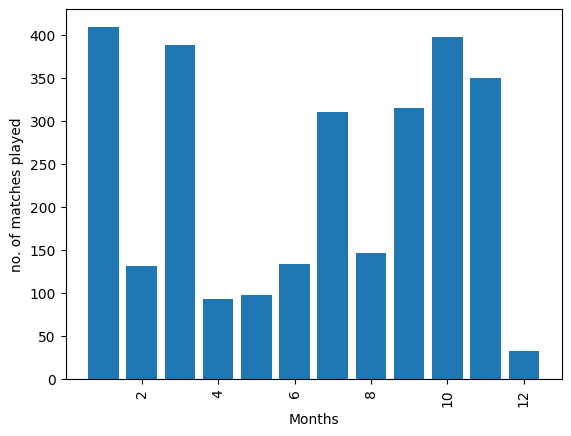

In [1122]:
plt.bar(month_counts['date_time_format'],month_counts['count'])
plt.xticks(rotation = 'vertical')
plt.xlabel('Months')
plt.ylabel('no. of matches played')
plt.show()

In [1124]:
# we do no see any pattern why on specific months no. of matches or specific tournaments takes place and 
# on some months there is few tournaments.

# 9. Which players improve performance in later rounds?

Goal: Track a player’s average points scored in early rounds vs later rounds (e.g., Round 1 vs Semis/Finals).
→ Who tends to peak deeper into tournaments?

In [1130]:
md_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2804 entries, 0 to 2803
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tournament                               2804 non-null   object 
 1   city                                     2804 non-null   object 
 2   country                                  2804 non-null   object 
 3   date                                     2804 non-null   object 
 4   tournament_type                          2804 non-null   object 
 5   discipline                               2804 non-null   object 
 6   round                                    2804 non-null   object 
 7   winner                                   2804 non-null   int64  
 8   nb_sets                                  2804 non-null   int64  
 9   retired                                  2804 non-null   bool   
 10  game_1_score                             2804 no

In [1263]:
# Calculate the mean total points for each unique team (ignoring rounds)
team_average_points = md_clean.groupby(
    ['team_one_player_one', 'team_one_player_two','round']
)['team_one_total_points'].mean().reset_index(name='overall_team_mean')
team_average_points

,team_one_player_one,team_one_player_two,round,overall_team_mean
0,Aaron Chia,Wooi Yik Soh,Final,46.000000
1,Aaron Chia,Wooi Yik Soh,Qualification quarter final,59.000000
2,Aaron Chia,Wooi Yik Soh,Quarter final,44.111111
3,Aaron Chia,Wooi Yik Soh,Round 1,42.000000
4,Aaron Chia,Wooi Yik Soh,Round 2,35.000000
...,...,...,...,...
1042,Zijian Di,Chang Wang,Round of 16,37.500000
1043,Zijian Di,Chang Wang,Round of 32,62.000000
1044,Zijian Di,Chang Wang,Semi final,48.666667
1045,Zvonimir Durkinjak,Sittichai Viboonsin,Qualification quarter final,42.000000


In [1277]:
# Calculate the max mean points for each team and round
round_average_df = round_average_series.reset_index()
rr1 = round_average_df.groupby(
    ['team_one_player_one', 'team_one_player_two']
)[['round','team_one_total_points']].max()
rr1 = rr1.reset_index()
rr1

,team_one_player_one,team_one_player_two,round,team_one_total_points
0,Aaron Chia,Wooi Yik Soh,Semi final,61
1,Adam Gozzi,Melker Z-Bexell,Qualification round of 16,42
2,Adarsh Kumar,Jagadish Yadav,Round of 32,20
3,Akbar Bintang Cahyono,Moh Reza Pahlevi Isfahani,Semi final,61
4,Akira Kobayashi,Kohtaro Miyajima,Round of 32,53
...,...,...,...,...
502,Zhiyi Dai,Kai Zheng,Round of 32,27
503,Zhuanyi Xuheng,Binrong Zhang,Round of 32,36
504,Zi Jian Di,Chang Wang,Semi final,61
505,Zijian Di,Chang Wang,Semi final,62


In [1309]:
rr2 = rr1.groupby('round')
rr2.get_group('Semi final')
rr2.get_group('Semi final').head()

,team_one_player_one,team_one_player_two,round,team_one_total_points
0,Aaron Chia,Wooi Yik Soh,Semi final,61
3,Akbar Bintang Cahyono,Moh Reza Pahlevi Isfahani,Semi final,61
5,Akira Koga,Taichi Saito,Semi final,64
21,Angga Pratama,Rian Agung Saputro,Semi final,60
28,Arun George,Sanyam Shukla,Semi final,42


In [1311]:
# these are the top 5 team1 who peaked in semifinals. no team in team1 peaked in Final.
# So these 5 teams can be considered that kept on playing good as the tournament proceeded
# same needs to be done for team 2

# 10. Visualize the score momentum of one iconic match

Goal: Pick one long match (e.g., a final with 3 sets) and plot the game_i_scores as a line chart showing point swings.
→ Can we see how momentum shifted?

In [1313]:
md_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2804 entries, 0 to 2803
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tournament                               2804 non-null   object 
 1   city                                     2804 non-null   object 
 2   country                                  2804 non-null   object 
 3   date                                     2804 non-null   object 
 4   tournament_type                          2804 non-null   object 
 5   discipline                               2804 non-null   object 
 6   round                                    2804 non-null   object 
 7   winner                                   2804 non-null   int64  
 8   nb_sets                                  2804 non-null   int64  
 9   retired                                  2804 non-null   bool   
 10  game_1_score                             2804 no

In [1325]:
final_match_3rd_set = md_clean[(md_clean['round']=='Final') & (md_clean['nb_sets']==3)]['game_3_scores'].reset_index()

In [1331]:
final_match_3rd_set

,index,game_3_scores
0,34,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '4-..."
1,69,"['0-0', '0-1', '0-2', '1-2', '1-3', '2-3', '2-..."
2,104,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '5-..."
3,290,"['0-0', '0-1', '1-1', '2-1', '2-2', '3-2', '4-..."
4,358,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '5-..."
5,392,"['0-0', '0-1', '1-1', '2-1', '3-1', '3-2', '4-..."
6,427,"['0-0', '1-0', '1-1', '1-2', '1-3', '2-3', '2-..."
7,796,"['0-0', '0-1', '1-1', '2-1', '2-2', '2-3', '3-..."
8,831,"['0-0', '0-1', '1-1', '1-2', '1-3', '1-4', '1-..."
9,897,"['0-0', '0-1', '0-2', '0-3', '1-3', '1-4', '1-..."


In [1335]:
third_set_points = final_match_3rd_set[final_match_3rd_set['index']==34]
third_set_points

,index,game_3_scores
0,34,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '4-..."


In [1371]:
third_set_points['game_3_scores']

0    ['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '4-...
Name: game_3_scores, dtype: object

In [1377]:
third_set_points['game_3_scores'][0]

"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '4-2', '5-2', '6-2', '6-3', '7-3', '7-4', '7-5', '7-6', '8-6', '9-6', '10-6', '11-6', '11-7', '11-8', '11-9', '11-10', '11-11', '11-12', '12-12', '12-13', '13-13', '14-13', '15-13', '15-14', '16-14', '16-15', '16-16', '17-16', '18-16', '18-17', '18-18', '19-18', '19-19', '19-20', '20-20', '20-21', '20-22']"

In [1405]:
third_set_points['game_3_scores'][0][16]

'2'

In [1407]:
import matplotlib.pyplot as plt
import ast

In [1409]:
# 1. Convert the string representation of a list into an actual list
score_list = ast.literal_eval(third_set_points['game_3_scores'][0])
score_list

['0-0',
 '1-0',
 '2-0',
 '2-1',
 '3-1',
 '4-1',
 '4-2',
 '5-2',
 '6-2',
 '6-3',
 '7-3',
 '7-4',
 '7-5',
 '7-6',
 '8-6',
 '9-6',
 '10-6',
 '11-6',
 '11-7',
 '11-8',
 '11-9',
 '11-10',
 '11-11',
 '11-12',
 '12-12',
 '12-13',
 '13-13',
 '14-13',
 '15-13',
 '15-14',
 '16-14',
 '16-15',
 '16-16',
 '17-16',
 '18-16',
 '18-17',
 '18-18',
 '19-18',
 '19-19',
 '19-20',
 '20-20',
 '20-21',
 '20-22']

In [1411]:
# Initialize lists for X and Y coordinates
x_coords = []
y_coords = []

# 2. Extract X and Y coordinates
for score_pair in score_list:
    x_str, y_str = score_pair.split('-')
    x_coords.append(int(x_str))
    y_coords.append(int(y_str))

In [1415]:
y_coords

[0,
 0,
 0,
 1,
 1,
 1,
 2,
 2,
 2,
 3,
 3,
 4,
 5,
 6,
 6,
 6,
 6,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 12,
 13,
 13,
 13,
 13,
 14,
 14,
 15,
 16,
 16,
 16,
 17,
 18,
 18,
 19,
 20,
 20,
 21,
 22]

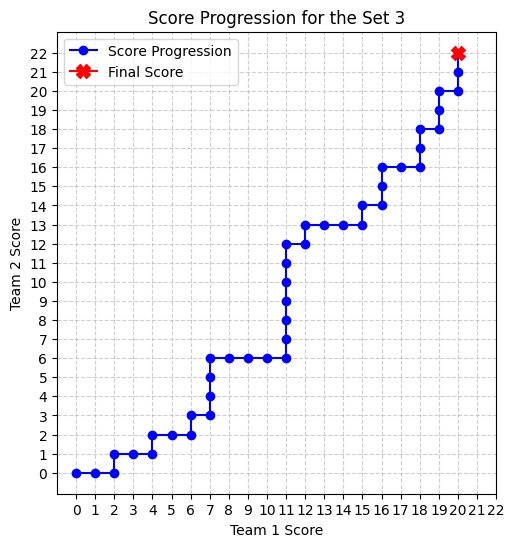

In [1421]:
# 3. Plot the data
plt.figure(figsize=(12, 6))
max_score = max(max(x_coords), max(y_coords))
plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='blue', label='Score Progression')
plt.plot(x_coords[-1], y_coords[-1], marker='X', markersize=10, color='red', label='Final Score')



# ... (set xlim/ylim to ensure the full range is covered)

# **Key Change: Set explicit tick marks for every integer point**
tick_marks = np.arange(0, max_score + 1, 1) # Create an array from 0 up to 22


# Add labels and title
plt.xlabel("Team 1 Score")
plt.ylabel("Team 2 Score")
plt.title(f"Score Progression for the Set 3")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.xticks(tick_marks)
plt.yticks(tick_marks)
plt.show()